In [2]:
"Initialize"
%load_ext autoreload
%autoreload
import matplotlib.pyplot as plt
import phaseco as pc
import os
import numpy as np
import pandas as pd
from collections import defaultdict


# Directories
dir_otocoh = r"C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence"
dir_figs = os.path.join(dir_otocoh, 'ARO', 'figs')
dir_figs_poster = r"C:\Users\setht\Dropbox\Citadel\FUSRP Research\2026 ARO\Poster\poster_figs"
dir_pkl = os.path.join(dir_otocoh, 'pickles', 'soae')
dir_results = os.path.join(dir_otocoh, "results", "soae")
dir_tau_pkl = os.path.join(dir_otocoh, 'pickles')

# Extra funcs
os.chdir(os.path.join(dir_otocoh, 'scripts'))
from helper_funcs import *

# We will work in the main otocoherence directory
os.chdir(dir_otocoh)

# Colors
human_color = "#8C60B3"
anole_color = "#07586E"

# Plot Equations
dpi = 1000


In [3]:
"Preparation"
# Switches
show_plot = 1
save_fig = 1

# Plotting params
alpha_static = 0.5
# strokecolor_stat = 'black'
strokecolor_dyn = 'black'
s = 50
s_stroke = s*1.2
fsz=20
labelpad_cgram=10


# Globals
nfft = 2**14
win_type = "flattop"
species_bws = {"Anole": 150, "Human": 50, "Owl": 300, "Tokay": 150}
markers = {
    "Anole": ("limegreen", "o"),
    "Owl": ("orange", "d"),
    "Human": ("blue", "x"),
    "Tokay": ("green", "+"),
}

mse_thresh = 0.001
xmin = 0.5
xmax = 12
ymin = 1
ymax = 2e3

# Define our methods
static_meth = {
    "win_meth": {"method": "static", "win_type": win_type},
    "hop_thing": ("int", 1),
    "bw_type": "species",
    "mode":'phi'
}

dynamic_meth = {
    "win_meth": {"method": "rho", "win_type": win_type, "rho": 1.0},
    "hop_thing": ("s", 0.01),
    "bw_type": 50,
    "mode":'phi'
}

# Excluded fits for terrible PSD HWHM fits
excluded_fits = [
    (
        "Owl",
        1,
        9258,
    ),
    ("Owl", 0, 4351),
    ("Anole", 3, 2783),
    ("Anole", 2, 1811),
]


# Define helper func to handle legend labels
def get_label_from_firsts(firsts, species):
    if firsts[species]:
        label = f"{species}"
        firsts[species] = 0
    else:
        label = None
    return label, firsts


# First, we gather everything from the two dataframes
N_xis = {}
T_xis = {}
freqs = {}
speciess = {}
titles = {}
mses = {}
wf_idxs = {}
hwhms = []
for method, regime in zip([static_meth, dynamic_meth], ["static", "dynamic"]):
    # Define strings
    bw_str = (
        f"BW=Species" if method["bw_type"] == "species" else f"BW={method['bw_type']}Hz"
    )
    win_meth_str = pc.get_win_meth_str(method["win_meth"])
    relevant_comp_str = rf"{win_meth_str}, {bw_str}, Mode={method['mode']}"
    # Define paths
    specific_dir_results = os.path.join(
        dir_results, rf"SOAE Results ({relevant_comp_str})"
    )
    N_xi_fitted_parameters_fp = os.path.join(
        specific_dir_results, rf"SOAE N_xi Fitted Parameters ({relevant_comp_str}).xlsx"
    )
    # Read df
    df = pd.read_excel(N_xi_fitted_parameters_fp)
    # Gather in lists
    wf_idxs[regime] = df["WF Index"]
    N_xis[regime] = df["N_xi"]
    T_xis[regime] = df["T_xi"]
    freqs[regime] = df["Frequency"]
    speciess[regime] = df["Species"]
    titles[regime] = f"Mode={method['mode']}, {bw_str}, {win_meth_str}"
    mses[regime] = df["MSE"]
    # Only the statics had a corresponding HWHM fit 
    if regime == "static":
        hwhms = df["L_gamma"]



Plotting HWHM vs T_xi (static, linear)
Excluding Anole 1 3023Hz
Excluding Anole 2 1811Hz
Excluding Anole 3 2140Hz
Excluding Anole 3 2417Hz
Excluding Anole 3 2783Hz
Excluding Tokay 0 4211Hz
Excluding Tokay 2 1837Hz
Excluding Tokay 2 2579Hz
Excluding Owl 0 4351Hz
Excluding Owl 1 9258Hz
Excluding Owl 2 5626Hz
Excluding Owl 3 5768Hz
Excluding Human 0 2805Hz
Excluding Human 2 1634Hz
Plotting HWHM vs T_xi (dynamic, linear)
Excluding Anole 2 1811Hz
Excluding Anole 3 2783Hz
Excluding Owl 0 4351Hz
Excluding Owl 1 9258Hz


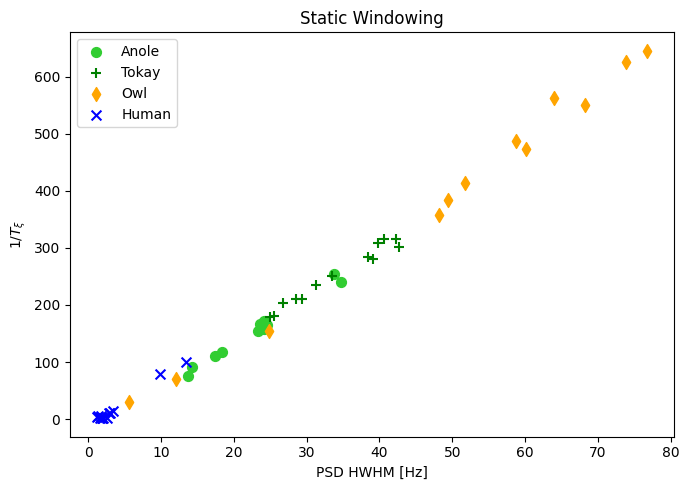

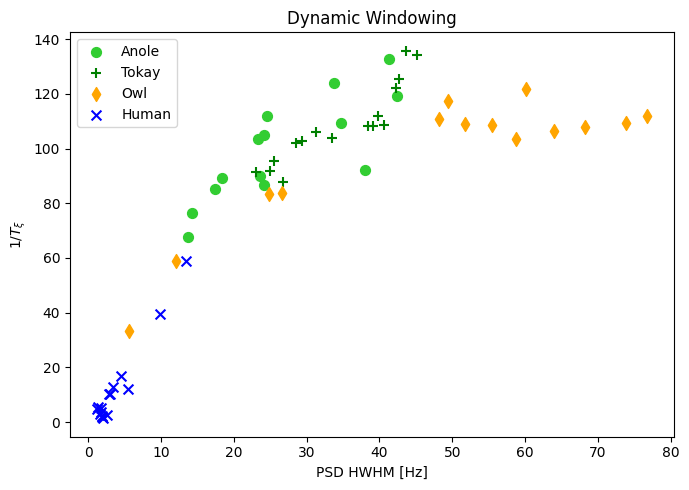

In [30]:

"Plot HWHM vs T_xi (static)"

for version in [0, 1]:
    match version:
        case 0:
            regime = 'static'
            xscale = 'linear'
            line_fit_overall = False
            line_fit_species = False
            fn_plot = f'HWHM vs T_xi ({regime}, {xscale})'
        case 1:
            regime = 'dynamic'
            xscale = 'linear'
            line_fit_overall = False
            line_fit_species = False
            fn_plot = f'HWHM vs T_xi ({regime}, {xscale})'
        case 2:
            regime = 'dynamic'
            xscale = 'log'
            line_fit_overall = False
            line_fit_species = False
            fn_plot = f'HWHM vs T_xi ({regime}, {xscale})'
    print(f"Plotting {fn_plot}")
    # Initialize Vars
    firsts = {"Anole": 1, "Owl": 1, "Human": 1, "Tokay": 1}
    hwhms_for_fit = defaultdict(list)
    inv_T_xis_for_fit = defaultdict(list)
    hwhms_for_fit_all = []
    inv_T_xis_for_fit_all = []
    # Initialize plot
    plt.figure(figsize=(7, 5))
    plt.title(rf"{regime.capitalize()} Windowing")
    for k in range(len(N_xis[regime])):
        wf_idx, species, freq, mse, T_xi, hwhm = (
            wf_idxs[regime][k],
            speciess[regime][k],
            freqs[regime][k],
            mses[regime][k],
            T_xis[regime][k],
            hwhms[k],
        )
        # Skip egregious static fits
        if mse > mse_thresh or (species, wf_idx, int(round(freq))) in excluded_fits:
            print(f"Excluding {species} {wf_idx} {freq:.0f}Hz")
            continue
        
        # Plot
        label, firsts = get_label_from_firsts(firsts, species)
        plt.scatter(
            hwhm,
            1 / T_xi,
            color=markers[species][0],
            marker=markers[species][1],
            zorder=1,
            label=label,
            s=s,
        )
        plt.legend()
        plt.xlabel(r"PSD HWHM [Hz]")
        plt.ylabel(r"$1/T_\xi$")
        # Add for later
        hwhms_for_fit[species].append(hwhm)
        hwhms_for_fit_all.append(hwhm)
        inv_T_xis_for_fit[species].append(1 / T_xi)
        inv_T_xis_for_fit_all.append(1 / T_xi)

    # Plot per-species line fits
    if line_fit_species:
        for species in speciess[regime].unique():
            p = np.polyfit(hwhms_for_fit[species], inv_T_xis_for_fit[species], 1)  # p[0] = slope, p[1] = intercept
            x = np.linspace(0, max(hwhms_for_fit[species]), 10)
            label = None
            # label = f'y={p[0]:.3g}x + {p[1]:.3g}'
            plt.plot(x, p[0]*x+p[1], label=label, color=markers[species][0], zorder=0)

    # Plot overall line fits
    if line_fit_overall:
        p = np.polyfit(hwhms_for_fit_all, inv_T_xis_for_fit_all, 1)  # p[0] = slope, p[1] = intercept
        x = np.linspace(0, max(hwhms_for_fit_all), 10)
        plt.plot(x, p[0]*x+p[1], label=f'y={p[0]:.3g}x + {p[1]:.3g}')

    plt.xscale(xscale)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(dir_figs_poster, fn_plot), dpi=dpi)


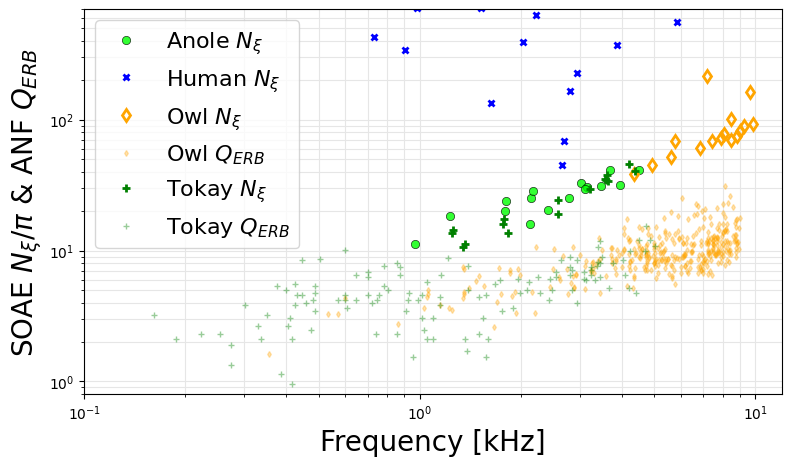

In [4]:
"Figure 3B"

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
fig_fp = os.path.join(dir_figs_poster, 'Qerb_vs_N_xi.jpg')
fp_N_xi= os.path.join(dir_otocoh, 'results','soae','SOAE Results (rho=1.0, Flattop, BW=50Hz, Mode=phi)', 'SOAE N_xi Fitted Parameters (rho=1.0, Flattop, BW=50Hz, Mode=phi).xlsx')

fact= 1/(np.pi);  # scaling factor for all Nxi {1/pi}
fact=1

# --- owl ANF tuning curve data (Excel files provided by Christine)
fp_ANFfileOwl= os.path.join(dir_otocoh, 'data','Owl Qerb_analysis_CK2.xlsx')

fp_ANFfileTokay= os.path.join(dir_otocoh, 'data', 'manley99.txt')
# ======================================================


# --- read in data
df = pd.read_excel(fp_N_xi)
owlANF= pd.read_excel(fp_ANFfileOwl)
toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

# ---------
# Get peak frequency and corresponding val to plot
anole_freqs = df[df['Species'] == 'Anole']['Frequency'].values
anole_Nxi = df[df['Species'] == 'Anole']['N_xi'].values
owl_freqs = df[df['Species'] == 'Owl']['Frequency'].values
owl_Nxi = df[df['Species'] == 'Owl']['N_xi'].values
human_freqs = df[df['Species'] == 'Human']['Frequency'].values
human_Nxi = df[df['Species'] == 'Human']['N_xi'].values

tokay_freqs = df[df['Species'] == 'Tokay']['Frequency'].values
tokay_Nxi = df[df['Species'] == 'Tokay']['N_xi'].values


# =========================
# deal w/ owl ANF vals
owlANF= owlANF[1:]  # discard first line
freqANFowl= owlANF['CF'].values
QerbANFowl= owlANF['Qerb'].values

# =========================
# deal w/ tokay ANF vals
freqANFtokay= toakyANFq10[:,0]
QerbANFtokay= 6*toakyANFq10[:,1]*1000/np.pi;  # convert to Qerb(?) via Bergevin & Shera 2010



# =======================================================================
# ==== visualize
plt.close("all")
# ------------------------------------------------
plt.figure(figsize=(9, 5))

# --- anole
fig1= plt.plot(anole_freqs/1000,anole_Nxi*fact,'o',color='k',markeredgewidth=0.5,
               alpha=0.8,ms=6,markerfacecolor='lime',label=r'Anole $N_{\xi}$')

# --- human
fig1= plt.plot(human_freqs/1000,human_Nxi*fact,'x',color='blue',
               alpha=1,ms=5,markeredgewidth=2,markerfacecolor='none',label=r'Human $N_{\xi}$')

# --- owl
fig1= plt.plot(owl_freqs/1000,owl_Nxi*fact,'d',color='orange',
               alpha=1.0,ms=6,markeredgewidth=2,markerfacecolor='none',label=r'Owl $N_{\xi}$')

fig1= plt.plot(freqANFowl,QerbANFowl,'d',color='orange',
               alpha=0.3,ms=3,lw=1,markerfacecolor='orange',label=r'Owl $Q_{ERB}$')

# --- tokay
fig1= plt.plot(tokay_freqs/1000,tokay_Nxi*fact,'+',color='green',
               alpha=1,ms=6,markeredgewidth=2,markerfacecolor='none',label=r'Tokay $N_{\xi}$')
fig1= plt.plot(freqANFtokay,QerbANFtokay,'+',color='green',
               alpha=0.4,ms=4,lw=1,markerfacecolor='green',label=r'Tokay $Q_{ERB}$')

# ---
plt.xscale('log')
plt.yscale('log')

plt.xlim([0.1,12])
plt.ylim([0.8,700])
plt.xlabel('Frequency [kHz]', fontsize=fsz)
plt.ylabel(r'SOAE $N_{\xi}/\pi$ & ANF $Q_{ERB}$', fontsize=fsz) 
plt.grid(True, which="both", ls="-", color='0.9')
plt.legend(fontsize=fsz-4)
 
plt.savefig(fig_fp, dpi=dpi, bbox_inches='tight')
plt.show()

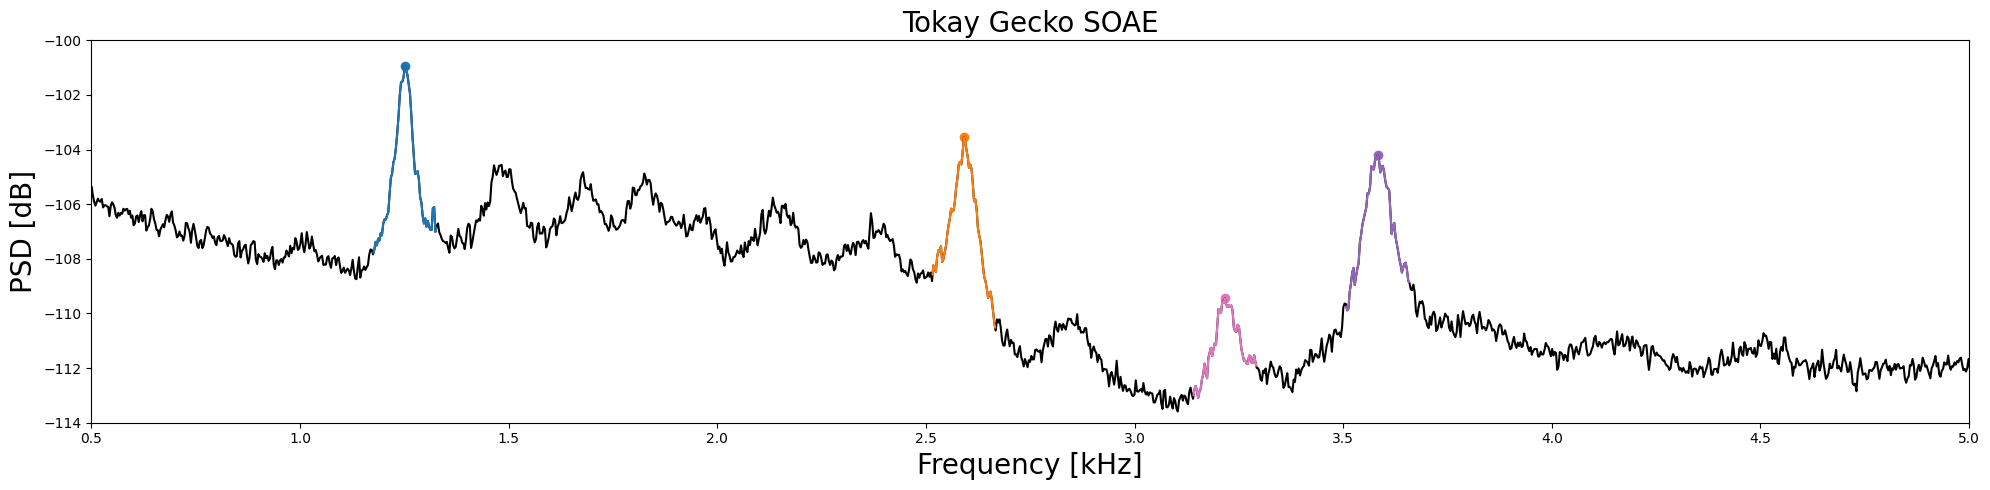

In [37]:
"Tokay PSD"

species='Tokay'
wf_idx=3
fp_fig=os.path.join(dir_figs_poster, f"{species}_{wf_idx}_PSD.jpg")

wf, wf_fn, fs, good_peak_freqs, bad_peak_freqs = get_wf(species=species, wf_idx=wf_idx)
good_colors = get_colors("good")
bad_colors = get_colors("bad")
bw = 150
wf_len_s = 60
wf = crop_wf(wf, fs, wf_len_s)

"PARAMETERS"
plot = 0
check_guesses = 1
tau = 2**14
hop = 2**13
win_type = 'hann'
# Everyone can use the same tau; slightly less finegrained for owl but it's already way oversampled

# Get peak bin indices
fn_id = rf"{species} {wf_idx}, $\tau={tau / fs *1000:.0f}$ms, wf_length={wf_len_s:.3f}s"
f_psd, psd = pc.get_welch(wf=wf, fs=fs, tau=tau, hop=hop, win=win_type)
psd_db = 10*np.log10(psd)
f_psd_khz = f_psd/1000
good_peak_idxs_psd = np.argmin(
    np.abs(good_peak_freqs[:, None] - f_psd[None, :]),
    axis=1,
)
bad_peak_idxs_psd = np.argmin(
    np.abs(bad_peak_freqs[:, None] - f_psd[None, :]),
    axis=1,
)

# PSD plot
plt.figure(figsize=(20, 5))
plt.plot(f_psd_khz, psd_db, label="PSD", color="k")
bw_khz = bw / 1e3
for peak_idxs_psd, colors in zip(
    [good_peak_idxs_psd, bad_peak_idxs_psd],
    [good_colors, bad_colors],
):
    for peak_idx_psd, color in zip(peak_idxs_psd, colors):
        plt.scatter(
            f_psd_khz[peak_idx_psd],
            psd_db[peak_idx_psd],
            c=color,
        )
        f0_khz = f_psd_khz[peak_idx_psd]
        # Color according to bandwidth
        a, b = f0_khz - bw_khz / 2, f0_khz + bw_khz / 2

        # Interpolate so you get exact endpoints
        ya = np.interp(a, f_psd_khz, psd_db)
        yb = np.interp(b, f_psd_khz, psd_db)

        # Restrict x,y to the band plus the interpolated endpoints
        mask = (f_psd_khz >= a) & (f_psd_khz <= b)
        f_band = np.concatenate(([a], f_psd_khz[mask], [b]))
        psd_band = np.concatenate(
            ([ya], psd_db[mask], [yb])
        )
        plt.plot(
            f_band,
            psd_band,
            c=color,
        )
plt.xlabel("Frequency [kHz]", fontsize=fsz)
plt.ylabel("PSD [dB]", fontsize=fsz)
plt.xlim(0.5, 5)
plt.ylim(-114, -100)
plt.title(rf"Tokay Gecko SOAE", fontsize=fsz)
plt.tight_layout()
plt.savefig(fp_fig, dpi=dpi)
plt.show()




Processing 'C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence\pickles\soae\Tokay 3, mode=phi, Static Flattop, hop=500, tau=1242, filter=None, xi_max=100ms, delta_xi=0.5ms, nfft=16384, N_pd=max, DM=True, wf_len=60s, wf=tokay_GG4rearSOAEwf (Colossogram).pkl'


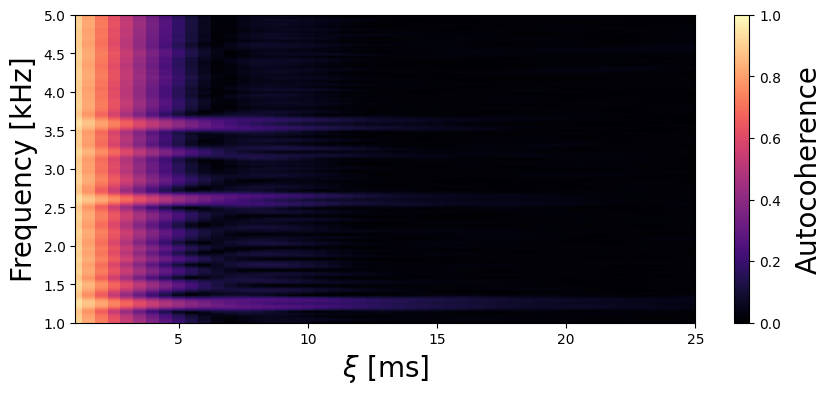

In [ ]:
"Tokay Colossogram"

species='Tokay'
wf_idx=3
fp_fig=os.path.join(dir_figs_poster, f"{species}_{wf_idx}_Colossogram.jpg")

wf, wf_fn, fs, good_peak_freqs, bad_peak_freqs = get_wf(species=species, wf_idx=wf_idx)
good_colors = get_colors("good")
bad_colors = get_colors("bad")
bw = 150
wf_len_s = 60
wf = crop_wf(wf, fs, wf_len_s)
tau = get_precalc_tau_from_bw(bw, fs, 'flattop', dir_tau_pkl)

cgram_dict = load_calc_colossogram(
    **{
        "wf": wf,
        "wf_idx": wf_idx,
        "wf_fn": wf_fn,
        "wf_len_s": wf_len_s,
        "species": species,
        "fs": fs,
        "pkl_folder": dir_pkl,
        "mode": 'phi',
        "tau": tau,
        "nfft": 16384,
        "xi_min_s": 0.0005,
        "xi_max_s": 0.1,
        "hop": get_hop_from_hop_thing(("s", 0.01), tau, fs),
        "filter_meth": None,
        "win_meth": {'method':'static', 'win_type':'flattop'},
        "demean": True,
        "const_N_pd": False,
        "scale": True,
    }
)
plt.figure(figsize=(10, 4))
cbar=pc.plot_colossogram(cgram_dict, cmap='magma', vmax=1.0, return_cbar=True)
cbar.set_label(r"Autocoherence", fontsize=fsz, labelpad=labelpad_cgram)
plt.ylabel("Frequency [kHz]", fontsize=fsz)
plt.xlabel(r"$\xi$ [ms]", fontsize=fsz)
plt.ylim(1, 5)
plt.xlim(1, 25)
plt.savefig(fp_fig, dpi=dpi, bbox_inches='tight')


Processing 'C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence\pickles\soae\Tokay 3, mode=phi, rho=1.0, Flattop, hop=500, tau=3725, filter=None, xi_max=50ms, delta_xi=0.5ms, nfft=16384, N_pd=max, DM=True, wf_len=60s, wf=tokay_GG4rearSOAEwf (Colossogram).pkl'


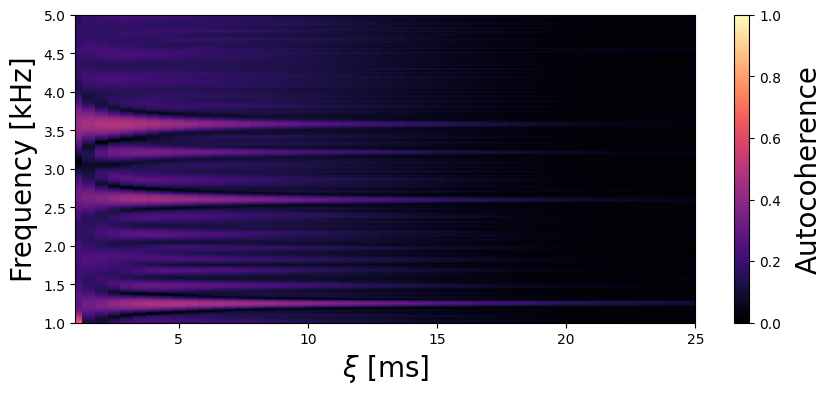

In [ ]:
"Tokay Colossogram"

species='Tokay'
wf_idx=3
fp_fig=os.path.join(dir_figs_poster, f"{species}_{wf_idx}_Colossogram_Dynamic.jpg")

wf, wf_fn, fs, good_peak_freqs, bad_peak_freqs = get_wf(species=species, wf_idx=wf_idx)
good_colors = get_colors("good")
bad_colors = get_colors("bad")
bw = 50
wf_len_s = 60
wf = crop_wf(wf, fs, wf_len_s)
tau = get_precalc_tau_from_bw(bw, fs, 'flattop', dir_tau_pkl)

cgram_dict = load_calc_colossogram(
    **{
        "wf": wf,
        "wf_idx": wf_idx,
        "wf_fn": wf_fn,
        "wf_len_s": wf_len_s,
        "species": species,
        "fs": fs,
        "pkl_folder": dir_pkl,
        "mode": 'phi',
        "tau": tau,
        "nfft": 16384,
        "xi_min_s": 0.0005,
        "xi_max_s": 0.05,
        "hop": get_hop_from_hop_thing(("s", 0.01), tau, fs),
        "filter_meth": None,
        "win_meth": {'method':'rho', 'rho':1.0, 'win_type':'flattop'},
        "demean": True,
        "const_N_pd": False,
        "scale": True,
    }
)
plt.figure(figsize=(10, 4))
cbar=pc.plot_colossogram(cgram_dict, vmax=1.0, cmap='magma', return_cbar=True)
cbar.set_label(r"Autocoherence", fontsize=fsz, labelpad=labelpad_cgram
)
plt.ylabel("Frequency [kHz]", fontsize=fsz)
plt.xlabel(r"$\xi$ [ms]", fontsize=fsz)
plt.ylim(1, 5)
plt.xlim(1, 25)
plt.savefig(fp_fig, dpi=dpi, bbox_inches='tight')


For tokay_GG1rearSOAEwf.mat we use [1343 1779 3650 4211]
Processing 'C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence\pickles\soae\Tokay 0, mode=phi, rho=1.0, Flattop, hop=500, tau=3725, filter=None, xi_max=100ms, nfft=16384, N_pd=max, DM=True, wf_len=60s, wf=tokay_GG1rearSOAEwf (Colossogram).pkl'
For JIrearSOAEwf2.mat we use [2339 4051 5838 8309]
Processing 'C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence\pickles\soae\Human 1, mode=phi, rho=1.0, Flattop, hop=441, tau=3285, filter=None, xi_max=1000ms, nfft=16384, N_pd=max, DM=True, wf_len=60s, wf=JIrearSOAEwf2 (Colossogram).pkl'
For owl_TAG4learSOAEwf1.mat we use [4945 5768 7184 9633]
Processing 'C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence\pickles\soae\Owl 3, mode=phi, rho=1.0, Flattop, hop=441, tau=3285, filter=None, xi_max=100ms, nfft=16384, N_pd=max, DM=True, wf_len=60s, wf=owl_TAG4learSOAEwf1 (Colossogram).pkl'
For AC6rearSOAEwfB1.mat we use [1235 2153 3704 4500]
Processing 'C:\Users\setht\Dropbox\Citadel\GitHub\otocohe

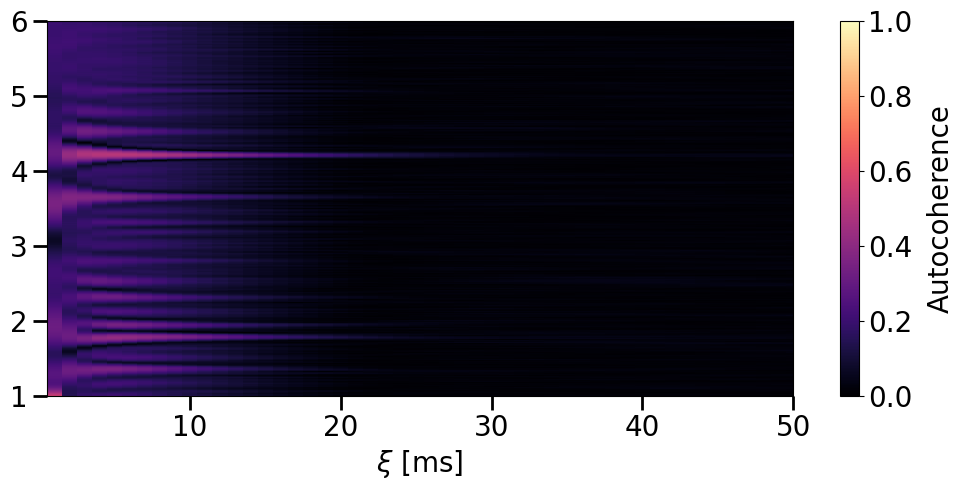

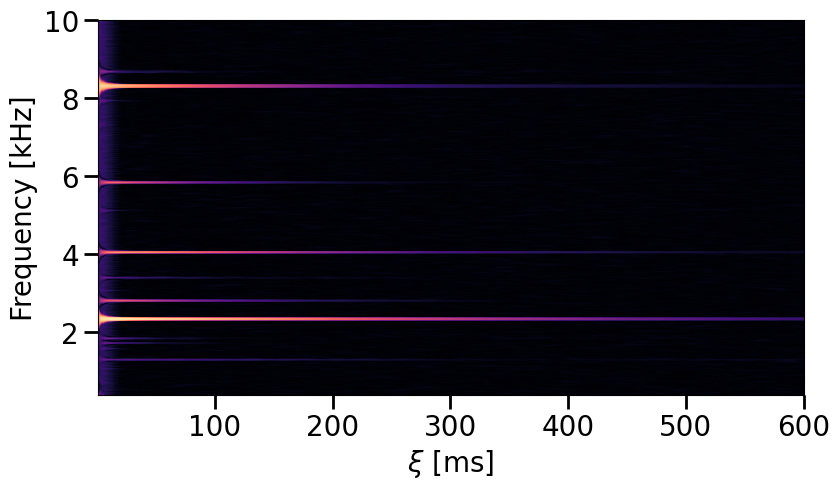

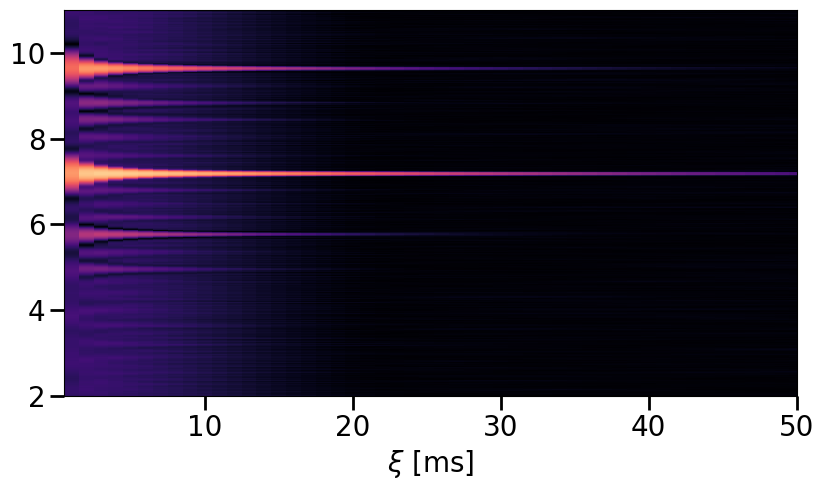

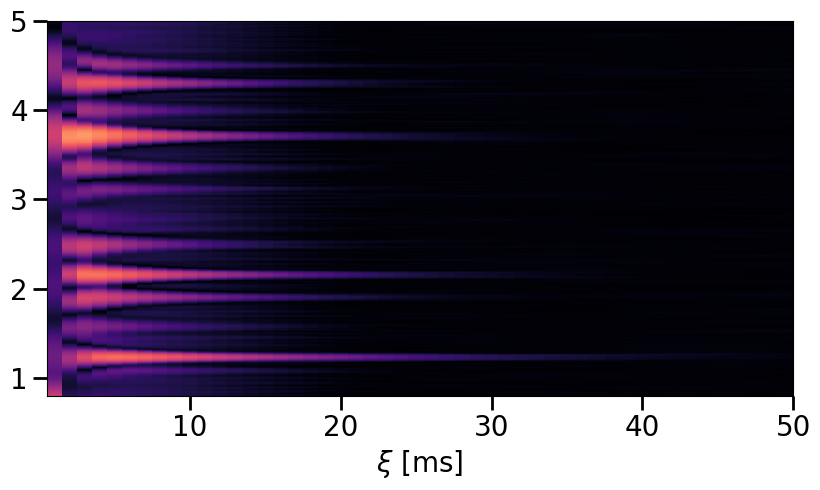

In [29]:
"All colossograms"
subjects = [('Tokay', 0), ('Human', 1), ('Owl', 3), ('Anole', 0)]
flims = {'Human':(0.4, 10), 'Owl':(2, 11), 'Anole':(0.8, 5), 'Tokay':(1, 6)}
hops = {'Human':441, 'Owl':441, 'Anole':441, 'Tokay':500}
xi_max_ss = {'Human':1.0, 'Owl':0.1, 'Anole':0.1, 'Tokay':0.1}
cgram_xmaxs = {'Human':600, 'Owl':50, 'Anole':50, 'Tokay': 50}

# Global params
bw = 50
freq_bin_hop = 1
mode = 'phi'
win = 'boxcar'
win_type_cgram = 'flattop'
win_meth_cgram = {'method':'rho', 'rho':1.0, 'win_type':win_type_cgram}
lcc_kwargs = {
    "wf_len_s": 60,
    "filter_meth": None,
    "mode":'phi',
    "xi_min_s": 0.001,
    "win_meth": win_meth_cgram,
    "nfft": 2**14,
    "pkl_folder": dir_pkl,
}
for (species, wf_idx) in subjects:
    "First two rows"
    # Get waveform
    wf, wf_fn, fs, good_peak_freqs, _ = get_wf(species=species, wf_idx=wf_idx)
    print(f"For {wf_fn} we use {good_peak_freqs}")
    # Preprocess
    wf-=np.mean(wf)
    
    # Get each subject specific param
    flim = flims[species]
    hop = hops[species]

    "Colossogram Plot"
    # Get waveform
    wf, wf_fn, fs, _, _ = get_wf(species=species, wf_idx=wf_idx)
    # Preprocess
    wf-=np.mean(wf)
    tau_cgram = get_precalc_tau_from_bw(bw, fs, win_type_cgram, dir_tau_pkl)
    # Load Colossogram
    cgram_dict = load_calc_colossogram(
        **(
            lcc_kwargs
            | {
                "xi_max_s": xi_max_ss[species],
                "species": species,
                "fs": fs,
                "tau": tau_cgram,
                "hop": hop,
                "wf": wf,
                "wf_idx": wf_idx,
                "wf_fn": wf_fn,
            }
        )
    )


    # Load everything that wasn't explicitly "saved" in the filename
    colossogram = cgram_dict["colossogram"]
    fn_id = cgram_dict["fn_id"]
    win_meth_str = cgram_dict["win_meth_str"]
    method_id = cgram_dict["method_id"]
    filter_str = cgram_dict["filter_str"]
    f = cgram_dict["f"]
    xis_s = cgram_dict["xis_s"]
    # good_peak_idxs = np.argmin(np.abs(f[:, None] - good_peak_freqs[None, :]), axis=0)
    # method_id = rf"[$\tau$={(tau/fs)*1000:.2f}ms]   [Mode=$\phi$]   [{win_meth_str}]   [Hop={hop_s*1000:.1f}ms]   [{N_pd_str}]   [nfft={nfft}]"
    suptitle = (
        rf"[{species} {wf_idx}]   [{wf_fn}]   [HPBW={bw}Hz]   {method_id}   [{filter_str}]"
    )

    # MAKE PLOT
    plt.figure(figsize=(10, 5))
    cbar = pc.plot_colossogram(cgram_dict, cmap="magma", return_cbar=True)
    cbar.set_label("Autocoherence", labelpad=labelpad_cgram)
    # Set Chris' requested fontsizes
    ax = plt.gca()
    ax.set_xlabel(r"$\xi$ [ms]", fontsize=fsz)
    ax.set_ylabel("Frequency [kHz]", fontsize=fsz) if species == 'Human' else ax.set_ylabel(None)
    ax.tick_params(axis='both', which='major', length=10, width=2)
    ax.tick_params("both", labelsize=fsz)
    cbar.ax.yaxis.label.set_fontsize(fsz)
    cbar.ax.tick_params(labelsize=fsz)
    if species != 'Tokay':
        cbar.ax.remove()

    plt.ylim(flim)
    plt.xlim(None, cgram_xmaxs[species])
    plt.tight_layout()
    plt.savefig(
        os.path.join(dir_figs_poster, f"Colossogram ({species}).jpg"),
        dpi=dpi,
        bbox_inches='tight'
    )
  


    
    

# of mag-avgd peaks found = 90 
# of C_xi^M peaks found = 183 
% increase in # of peaks found = 103.33% 


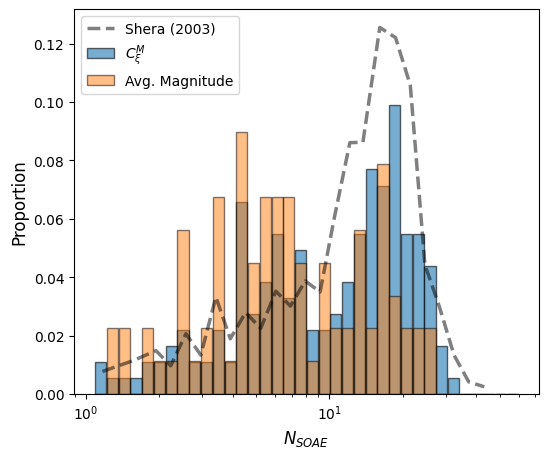

In [58]:
"Figure 4CDE"
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import os



# -----------------------------
# function to extract Nsoae and geomean freq from SOAE peak array
def computeNsoae(arr):
    tempARR= arr
    cnt= 0
    M= len(tempARR)  # numb. of peaks
    Mint= M-1   # only consider adjacent peak pairs
    nsoae= np.empty([Mint])
    geofreq= np.empty([Mint])
    # --- only adjacent neighboring pairs
    for nn in range(0,M-1):
        fL= tempARR[nn]*1000 # pick off lowest freq. yet to analyze  [Hz]
        fH= tempARR[nn+1]*1000  # higher freq. of the pair [Hz]
        freqGM= np.sqrt(fH*fL)  # geometric mean freq.
        freqDiff= fH-fL
        geofreq[cnt]= freqGM  # stored geometric mean freq. [Hz]
        nsoae[cnt]= freqGM/freqDiff # stored Nsoae
        cnt= cnt+1
        
    return geofreq, nsoae


"Filepaths"
method_id_N_xi = 'rho=1.0, Flattop, BW=50Hz, Mode=phi'
fp_N_xi= os.path.join('results', 'soae', f'SOAE Results ({method_id_N_xi})', f'SOAE N_xi Fitted Parameters ({method_id_N_xi}).xlsx')
ssheet_fp = os.path.join('results', 'soae', 'Human Peak Picks (Fig.4)', 'Mags vs C_xi_M Picked Peaks.xlsx')

"Build arrays from spreadsheet"
# Load Excel file into two DataFrames
df_mags = pd.read_excel(ssheet_fp, sheet_name='Mags')
df_C = pd.read_excel(ssheet_fp, sheet_name='C_xi_M')
# Get all the filenames
wf_fns = np.array(df_mags.columns.to_list())
N_wfs = len(wf_fns)
# Initialize final arrays to build
all_geofreqs_mags = []
all_geofreqs_C = []
all_Nsoae_mags = []
all_Nsoae_C = []
all_freq_ratios_C = []
each_geofreqs_C = np.empty(shape=(N_wfs), dtype=list)
each_Nsoae_C = np.empty(shape=(N_wfs), dtype=list)
for k, wf_fn in enumerate(wf_fns):
    # Get freqs
    peak_freqs_mags = df_mags[wf_fn].dropna().to_numpy()
    peak_freqs_C = df_C[wf_fn].dropna().to_numpy()
    # Sort by increasing frequency
    peak_freqs_mags = np.sort(peak_freqs_mags)
    peak_freqs_C = np.sort(peak_freqs_C)
    # Compute Nsoae and geometric mean freqs
    geofreqs_mags, Nsoae_mags = computeNsoae(peak_freqs_mags)
    geofreqs_C, Nsoae_C = computeNsoae(peak_freqs_C)
    # Compute freq ratios (higher/lower)
    ratios_C = peak_freqs_C[1:] / peak_freqs_C[:-1]
    # Add to overall lists
    all_geofreqs_mags.extend(geofreqs_mags)
    all_geofreqs_C.extend(geofreqs_C)
    all_Nsoae_mags.extend(Nsoae_mags)
    all_Nsoae_C.extend(Nsoae_C)
    all_freq_ratios_C.extend(ratios_C)
    each_geofreqs_C[k] = geofreqs_C
    each_Nsoae_C[k] = Nsoae_C
# Convert to ndarray
all_geofreqs_mags = np.array(all_geofreqs_mags)
all_geofreqs_C = np.array(all_geofreqs_C)
all_Nsoae_mags = np.array(all_Nsoae_mags)
all_Nsoae_C = np.array(all_Nsoae_C)
all_freq_ratios_C = np.array(all_freq_ratios_C)
# Compute freq diffs
freq_diffs_C= all_geofreqs_C/all_Nsoae_C



"Chris' original plotting code"
# ======================================================
binsN= 37    # number of bins for Nsoae histogram
N = 1000   # number of times to bootstrap re xi-adjusted power law fit
ratioBinCNT= 200   # numb. of bins for freq. ratio histogram
fact= 1/(8*np.pi);  # scaling factor for all Nxi {1/4pi}
show_plots = 1
save_plots = 1
# ======================================================


# --- send some vals to screen for ref
print(f'# of mag-avgd peaks found = {str(len(all_geofreqs_mags))} ')
print(f'# of C_xi^M peaks found = {str(len(all_geofreqs_C))} ')
percent_inc= 100*(len(all_geofreqs_C)-len(all_geofreqs_mags) )/len(all_geofreqs_mags)
print(f'% increase in # of peaks found = {percent_inc:.2f}% ')




# =======================================================================
# ==== Shera 2003 Nsoae vals
# (previously computed for CB 2012 HR paper; vals. extracted from older analysis
# code: ...//Users/pumpkin/Dropbox/Collaborations B/Oldenburg/Analysis/
#    /2014 MoH owl/Analysis/2012 HR human analysis codesModelPredictN2.m

Shera03n=np.array([1.1686,1.5560,1.9393,2.2290,2.5734,2.9629,3.4175,3.9169,
    4.5260,5.2217,6.0284,6.9145,7.9564,9.1602,10.4685,12.1349,13.7273,
   16.1044,18.6965,21.4918,24.6847,28.2800,32.4947,37.3661,43.2892])
Shera03cnt=np.array([4.2852,6.3118,8.2251,5.3621,11.4314,7.3887,18.3734,10.4826,
   15.4564,12.4530,19.4773,16.6705,21.4195,19.3430,33.3050,47.6042,
   47.6622,69.4051,67.4692,58.4829,24.4698,16.6070,7.3961,2.3141,1.3894])




# ------------------------------------------------
# ------------------------------------------------
# --- grab a subset of Nsoae vals above a certain min. val.
# (a la Shera 2003 analysis to "the peak of the distribution [...]
# To reduce bias in the fit"
# NOTE: unless there is a good reason to utilize this set of #s, seems 
# wiser to avoid
NsoaeMIN= 0.75*np.mean(all_Nsoae_C)
gmTthresh= all_geofreqs_C[all_Nsoae_C>NsoaeMIN]
nTthresh= all_Nsoae_C[all_Nsoae_C>NsoaeMIN]


# =======================================================================
# ==== (single) Power Law fit (a la Shera 2003 approach)
# --
def powlawFunc(f,A,c):
    return A*(f**c)

# === do the fits via the  scipy blackbox
# --- standard spectral averaging peak freqs
paramsS, covarS = curve_fit(powlawFunc,all_geofreqs_mags,all_Nsoae_mags)
AfitS, cfitS = paramsS
# --- xi-adjusted temporal averaging peak freqs
paramsT, covarT = curve_fit(powlawFunc,all_geofreqs_C,all_Nsoae_C)
AfitT, cfitT = paramsT
# --- Shera03-style "thresholded" vals.
paramsTthresh, covarTthresh = curve_fit(powlawFunc,gmTthresh,nTthresh)
AfitTthresh, cfitTthresh = paramsTthresh

# ==== compute fit curves to plot
fitF= np.logspace(np.log10(300),np.log10(max(all_geofreqs_C)), 50)
fitNS= powlawFunc(fitF,AfitS, cfitS)
fitNT= powlawFunc(fitF,AfitT, cfitT)
fitNTthresh= powlawFunc(fitF,AfitTthresh, cfitTthresh)
# --- Shera's fit vals (via Table I in 2003 paper)
fitFshera= np.logspace(np.log10(550),np.log10(7000), 50)
fitShera= powlawFunc(fitFshera/1000,13.7,0.31)


# =======================================================================
# ==== (bootstrapped I) Power Law fit --> amongst pooled datas
# [adapting bits from my EXstatBootstrap2.py code]

nbs= len(all_Nsoae_C)
#nbs= int(np.round(0.9*len(nTall)))
indx= np.arange(nbs)  # create array index 

for n in range(0,N):
    # === grab a resampled array 
    indxBS= np.random.choice(indx,replace=1,size=nbs)
    xT= all_geofreqs_C[indxBS] # 
    yT= all_Nsoae_C[indxBS] # 
    pTtemp, covarTtemp = curve_fit(powlawFunc,xT,yT,maxfev=2000)
    AfitTtemp, cfitTtemp = pTtemp
    fitTtemp= powlawFunc(fitF,AfitTtemp, cfitTtemp)
    # -- store away fits
    if n==0:
        yDf= fitTtemp  # kludgy
    else:
        yDf= np.vstack((yDf,fitTtemp)) 

# === determine mean and SD (& SE) from bootstrapped loess      
yDfitM= np.mean(yDf,0)  # mean loess fit
yDfitSD= np.std(yDf,axis=0)  # standard deviation
SE= yDfitSD/np.sqrt(N)  # " standard error
CI= 2*SE # confidence intervals (CIs) as +/-95% (i.e., 2*SE)


# =======================================================================
# ==== (bootstrapped II) Power Law fit --> amongst subjects
# Bootstrap resampling number (equal to number of subjects, 12)
nbs2= len(wf_fns)
# NOTE: can make this smaller if you want fewer resmapled subjects
indx2= np.arange(nbs2)  # create array index 
# --
for mm in range(0,nbs2-1):
    # Get a reproducible rng
    rng = np.random.default_rng(seed=24) 
    # === grab a resampled list of subject
    indxBS2 = rng.choice(indx2, size=nbs2, replace=True)
    xT2= []
    yT2= []
    # --- compile #s together via for loop (better way to do??)
    for nn in range(0,nbs2-1):
        # Replaced Chris' code 
        # xT2= np.concatenate((xT2,eval('gmT'+str(indxBS2[nn]+1))))
        # yT2= np.concatenate((yT2,eval('nT'+str(indxBS2[nn]+1))))
        # with the following equivalent code with my variables
        xT2.extend(each_geofreqs_C[indxBS2[nn]])
        yT2.extend(each_Nsoae_C[indxBS2[nn]])
    xT2 = np.array(xT2)
    yT2 = np.array(yT2)
    
    pTtemp2, covarTtemp2 = curve_fit(powlawFunc,xT2,yT2)
    AfitTtemp2, cfitTtemp2 = pTtemp2
    fitTtemp2= powlawFunc(fitF,AfitTtemp2, cfitTtemp2)
    # -- store away fits
    if mm==0:
        yDf2= fitTtemp2  # kludgy
    else:
        yDf2= np.vstack((yDf2,fitTtemp2))

# === determine mean and SD (& SE) from bootstrapped loess      
yDfitM2= np.mean(yDf2,0)  # mean loess fit
yDfitSD2= np.std(yDf2,axis=0)  # standard deviation
SE2= yDfitSD2/np.sqrt(N)  # " standard error
CI2= 2*SE2 # confidence intervals (CIs) as +/-95% (i.e., 2*SE)


# =======================================================================
# ==== create histogram of Nsoae vals (akin to Fig.2 of Shera 2003)
log_bins = np.logspace(np.log10(all_Nsoae_C.min()), np.log10(all_Nsoae_C.max()),binsN) 
log_binsShera = np.logspace(np.log10(Shera03n.min()), np.log10(Shera03n.max()),len(Shera03n)) 
bin_centers = (log_bins[:-1] + log_bins[1:]) / 2
# --
countsT, binsREP = np.histogram(all_Nsoae_C,log_bins)
countsS, binsREP = np.histogram(all_Nsoae_mags,log_bins)



# =======================================================================
# -- determine average Nsoae vals. in oct.-wide bins (starting at 0.3 kHz)

freqOct= [300,600,1200,2400,4800,9600]  # oct. range bounds

avgN= []
stdN= []
serrN= []
avgGM= []
for pp in range(0,len(freqOct)-1):
    tmp0= len(all_Nsoae_C[np.where(np.logical_and(all_geofreqs_C>=freqOct[pp],all_geofreqs_C<freqOct[pp+1]))])
    tmp1= np.mean(all_Nsoae_C[np.where(np.logical_and(all_geofreqs_C>=freqOct[pp],all_geofreqs_C<freqOct[pp+1]))])
    tmp2= np.std(all_Nsoae_C[np.where(np.logical_and(all_geofreqs_C>=freqOct[pp],all_geofreqs_C<freqOct[pp+1]))])
    tmp3= np.mean(all_geofreqs_C[np.where(np.logical_and(all_geofreqs_C>=freqOct[pp],all_geofreqs_C<freqOct[pp+1]))])
    avgN.append(tmp1)
    stdN.append(tmp2)
    serrN.append(tmp2/np.sqrt(tmp0))
    avgGM.append(tmp3)
    
    
avgN= np.array(avgN)  # kludge
stdN= np.array(stdN)
serrN= np.array(serrN)
avgGM= np.array(avgGM)

#val1= np.mean(nTall[np.where(np.logical_and(gmTall>=300,gmTall<600))])
#std1= np.std(nTall[np.where(np.logical_and(gmTall>=300,gmTall<600))])

# --- also create the assoc. vers. of the freq. diff. from Shera's 2003
# power law fit


fDiffSheraPLoct= np.log2(fitFshera/fitShera)


# =======================================================================
# read in human Nxi vals.


# --- read in data
df = pd.read_excel(fp_N_xi)
human_freqs = df[df['Species'] == 'Human']['Frequency'].values
human_Nxi = df[df['Species'] == 'Human']['N_xi'].values


"Figure 4D"
# =======================================================================
# ==== visualize
if 0:
    plt.close("all")
    # ------------------------------------------------
    # Fig.4D - Nsoae vs freq. (along with various fits/comps)
    fig1, ax1 = plt.subplots()

    # --- plot all compiled points
    #fig1= plt.plot(gmSall/1000,nSall,'x',color='r',alpha=0.3,ms=5,markerfacecolor='none',label='Spectral Avg.')
    fig1= plt.scatter(all_geofreqs_mags/1000,all_Nsoae_mags,marker='x', color='darkorange',s=24,alpha=0.5,linewidths=2,label='Avg. Magnitude')
    fig1= plt.plot(all_geofreqs_C/1000,all_Nsoae_C,'s',color='royalblue',alpha=0.4,ms=4,markerfacecolor='royalblue',
                markeredgecolor='none',label=r'$C_\xi^M$')
    # --- plot power law fits
    #fig1= plt.plot(fitF/1000,fitNS,'r--',lw=1,label='Spectral Avg.')
    #fig1= plt.plot(fitF/1000,fitNT,'k-',lw=2,alpha=0.3,label='Power fit (all)')
    #fig1= plt.plot(fitF/1000,fitNTthresh,'c-',lw=3,label='Thresholded')
    fig1= plt.plot(fitFshera/1000,fitShera,'-.',lw=2,color='black',label='Shera (2003)')
    # --- plot bootstrapped power law fits (all data pooled for bootstrap)
    fig1= plt.plot(fitF/1000,yDfitM,'-',color='royalblue',lw=2,label='Bootstrapped power law fit')
    fig1= plt.fill_between(fitF/1000, (yDfitM-yDfitSD), (yDfitM+yDfitSD), 
                        color='royalblue',alpha=0.1)   
    # - Subj.-pooled bootstrapped fit?
    if (1==0):
        fig1= plt.plot(fitF/1000,yDfitM2,'-',color='magenta',lw=2,label='Subj.-pooled bootstrapped fit')
        fig1= plt.fill_between(fitF/1000, (yDfitM2-yDfitSD2), (yDfitM2+yDfitSD2), 
                            color='magenta',alpha=0.1)
    # --- plot mean oct-wide bin vals?
    if (1==1):
        #fig1= plt.plot(avgGM/1000,avgN,'^',color='magenta')
        # --- plotting w/ standard error
        fig1= plt.errorbar(avgGM/1000,avgN, yerr=serrN, fmt='d',capsize=4,lw=1,
                        color='blue',alpha=0.7,label='octave-wide averages')
        

    # --- bookeeping
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    fig1= plt.xlim([0.27,15])
    fig1= plt.ylim([1,300])
    fig1= plt.xlabel('Frequency [kHz]',fontsize=12)
    fig1= plt.ylabel(r"$N_{SOAE}$",fontsize=12) 
    #fig1= plt.title('Human Nsoae: Spec-avg. (triangle) vs xi-adjust. Temp.-avg. (dot)') 
    fig1= plt.grid(True, which="both", ls="-", color='0.9')
    ax1.set_axisbelow(True)
    fig1= plt.legend()
    if show_plots:
        plt.show()
    fp = os.path.join(dir_figs_poster, 'Fig4D')
    plt.savefig(fp, dpi=dpi, bbox_inches='tight')


"Figure 4C"
# ------------------------------------------------
# Fig.2 - Histogram of Nsoae
plt.figure(figsize=(6, 5))
# ---
plt.bar(bin_centers,countsT/np.sum(countsT),alpha=0.6,width=np.diff(log_bins),ec="k", align="edge",label=rf'$C_\xi^M$')
plt.bar(bin_centers,countsS/np.sum(countsS),alpha=0.5,width=np.diff(log_bins),ec="k",align="edge",label='Avg. Magnitude')
# ----
plt.plot(Shera03n,Shera03cnt/np.sum(Shera03cnt),'k--',lw=2.5,alpha=0.5,label='Shera (2003)')
plt.xscale('log') # Still useful to ensure proper display of log ticks
plt.xlabel(r"$N_{SOAE}$",fontsize=12)
plt.ylabel("Proportion",fontsize=12)
#plt.title(r'Comparison of $N_{SOAE}$')
plt.legend()
fp = os.path.join(dir_figs_poster, 'N_SOAE vs Shera')
plt.savefig(fp, dpi=dpi, bbox_inches='tight')
    



